# Classification Lab — Group B: Insurance Claim Fraud Prediction

| Key | Value |
|---|---|
| **Course** | BBT 4106  |
| **Group** | B1 |
| **Dataset** | `insurance_claim_fraud.csv` |
| **Target** | `Claim_Status` |
| **Members** | 148396 - Ida Aluso, 169884 - Derby Muchiri, 157608 - Bridgette Juma, 169007 - Brian Kioko, 169643-Charles Kabuga, 170160 - Kibiru Collins Kairuki |

**Educational context.** An insurance company wants a reliable system for identifying potentially fraudulent insurance claims using information about the claimant, policy, incident, and claim characteristics. Such a model can be used to (a) identify potentially fraudulent claims for further investigation, and (b) reduce financial losses and improve the efficiency of the claims assessment process.

This notebook follows a similar workflow to what was covered in class: EDA, train/test split, feature selection on training data only, preprocessing pipeline, class-imbalance handling, cross-validated model comparison, diagnostics, test-set evaluation, hyperparameter tuning, explainability, and persistence.


# Data Loading & EDA

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


## Load the  Data


Load the synthetic classification insuarance claim fraud dataset to understand the structure of the dataset and identify any potential issues

In [2]:
import os

dataset_path = "student_exam_score_placeholder"  # will be overwritten below
dataset_filename = "insurance_claim_fraud.csv"

# Prefer a local upload; fall back to common Colab locations.
candidate_paths = [
    dataset_filename,
    f"/content/{dataset_filename}",
    f"/content/sample_data/{dataset_filename}"
]

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path is None:
    raise FileNotFoundError(
        f"{dataset_filename} not found. In Colab: click the folder icon on the left "
        f"sidebar, then Upload, and select {dataset_filename} (or mount Google Drive "
        "and update csv_path)."
    )

claims_data = pd.read_csv(csv_path)

TARGET = "claim_status"

print(f"Loaded dataset from: {csv_path}")
print(f"Shape: {claims_data.shape[0]} rows, {claims_data.shape[1]} columns")
print(f"Target variable: {TARGET}")

claims_data.head()


FileNotFoundError: insurance_claim_fraud.csv not found. In Colab: click the folder icon on the left sidebar, then Upload, and select insurance_claim_fraud.csv (or mount Google Drive and update csv_path).

**Interpretation:**<br>
The insurance dataset was loaded successfully. It contains 1,600 rows and 16 columns with claim_status was identified as the target variable. The target classes depict whether the insuarance claim is legiti ate or fraudulent.

## Exploratory Data Analysis

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   claim_id                            1600 non-null   int64  
 1   policy_type                         1600 non-null   str    
 2   claim_type                          1600 non-null   str    
 3   incident_location_type              1600 non-null   str    
 4   witnesses_present                   1600 non-null   str    
 5   agent_flagged_history               1600 non-null   str    
 6   police_report_filed                 997 non-null    str    
 7   claimant_age                        1600 non-null   float64
 8   policy_tenure_years                 1600 non-null   float64
 9   prior_claims_count                  1600 non-null   int64  
 10  days_to_report_claim                1600 non-null   float64
 11  claim_amount_kes                 

,Min,Q1,Median,Q3,Max,Mean,Std Dev,Skewness,IQR
claimant_age,18.00,32.00,41.00,49.00,81.00,41.12,12.59,0.20,17.00
policy_tenure_years,0.20,2.70,4.70,7.52,30.00,5.68,4.10,1.48,4.82
prior_claims_count,0.00,0.00,1.00,1.00,6.00,0.90,0.99,1.19,1.00
days_to_report_claim,0.00,2.50,4.60,7.40,29.90,5.50,4.04,1.40,4.90
claim_amount_kes,5000.00,89257.25,153758.00,241897.50,873168.00,182854.23,129298.37,1.37,152640.25
estimated_repair_cost_kes,4717.00,88637.00,152065.50,242825.25,964198.00,183233.40,130629.23,1.39,154188.25
claim_amount_to_policy_limit_ratio,0.10,0.20,0.28,0.42,0.83,0.34,0.17,1.14,0.22
customer_credit_score,358.18,589.17,652.05,711.80,850.00,650.26,88.00,-0.14,122.63



Missing Values:


,Missing Count,Missing Percentage
police_report_filed,603,37.69
customer_credit_score,90,5.62



Target Class Distribution:


,Count,Percentage
claim_status,,
Legitimate,1504,94.0
Fraudulent,96,6.0


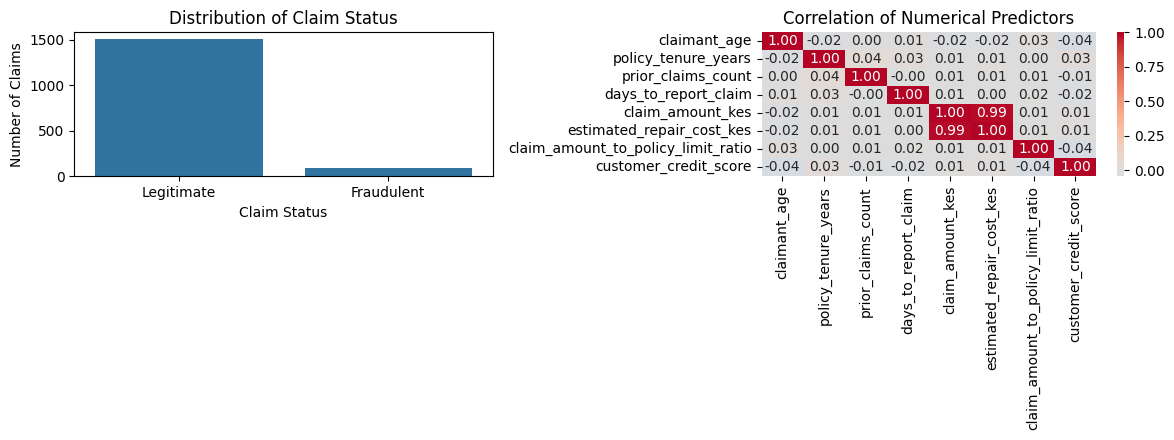

In [ ]:
# Identify numerical and categorical variables
numeric_cols = claims_data.select_dtypes(
    include=[np.number]
).columns.tolist()

categorical_cols = claims_data.select_dtypes(
    exclude=[np.number]
).columns.tolist()

# Remove ID and target from predictor lists
numeric_cols.remove("claim_id")
categorical_cols.remove(TARGET)

# Dataset information
print("Dataset Information:")
claims_data.info()

# Distribution summary
q1 = claims_data[numeric_cols].quantile(0.25)
q3 = claims_data[numeric_cols].quantile(0.75)
iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "Min": claims_data[numeric_cols].min(),
    "Q1": q1,
    "Median": claims_data[numeric_cols].median(),
    "Q3": q3,
    "Max": claims_data[numeric_cols].max(),
    "Mean": claims_data[numeric_cols].mean(),
    "Std Dev": claims_data[numeric_cols].std(),
    "Skewness": claims_data[numeric_cols].skew(),
    "IQR": iqr
})

print("\nNumerical Variables:")
print(numeric_cols)

print("\nCategorical Variables:")
print(categorical_cols)

print("\nDistribution Summary:")
display(distribution_summary.round(2))

# Missing values
missing_summary = pd.DataFrame({
    "Missing Count": claims_data.isnull().sum(),
    "Missing Percentage": (
        claims_data.isnull().mean() * 100
    ).round(2)
})

print("\nMissing Values:")
display(
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
)

# Class distribution
print("\nTarget Class Distribution:")
class_summary = pd.DataFrame({
    "Count": claims_data[TARGET].value_counts(),
    "Percentage": (
        claims_data[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})
display(class_summary)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(
    data=claims_data,
    x=TARGET,
    ax=axes[0]
)
axes[0].set_title("Distribution of Claim Status")
axes[0].set_xlabel("Claim Status")
axes[0].set_ylabel("Number of Claims")

sns.heatmap(
    claims_data[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)
axes[1].set_title("Correlation of Numerical Predictors")

plt.tight_layout()
plt.show()

**Interpretation**<br>
The dataset has 8 numerical predictors and 7 categorical predictors and this excluded the identifier and target variable. The target distribution is imbalanced because legitimate claims 1,504 (94%) values while fraudulent claims has 96 (6%) views. Also, missing values are presented in police_report_files and customer_credit_score. Finally, several numerical variables including claim amounts and policy related measured show positive skewness.

## Box Plot Analysis

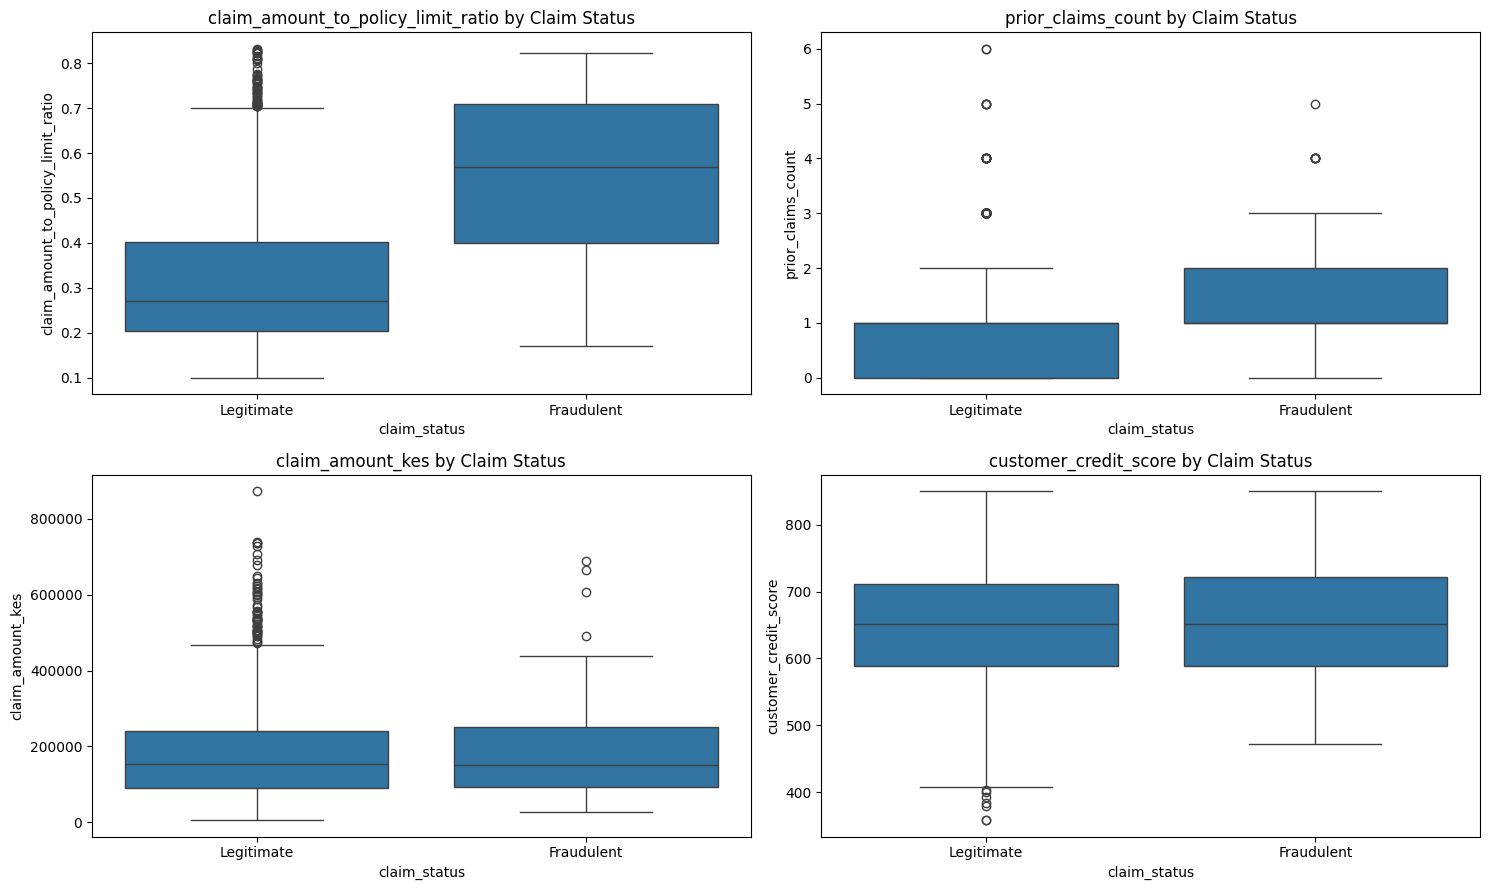

In [ ]:
# Box plots for selected numerical predictors by claim status

key_predictors = [
    "claim_amount_to_policy_limit_ratio",
    "prior_claims_count",
    "claim_amount_kes",
    "customer_credit_score"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, col in zip(axes.flatten(), key_predictors):
    sns.boxplot(
        data=claims_data,
        x=TARGET,
        y=col,
        order=["Legitimate", "Fraudulent"],
        ax=ax
    )
    ax.set_title(f"{col} by Claim Status")

plt.tight_layout()
plt.show()

The box plots were used to compare the numerical predictors across legitimate and fraudulent claims. The claim amount-to-pilicy-limit ratio shows clear difference between the 2 target classes, which suggest that it may be an important predictor of fraud. The other variables show some overlap between classes, indicating that the fraud detection will require a combination of predictors rather than reliance on one variable.

# 2. Split Discipline

##Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = [
    c for c in claims_data.columns
    if c not in ["claim_id", TARGET]
]

X = claims_data[feature_cols].copy()
y = claims_data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 1280 rows
Test set: 320 rows

Training class proportions:
claim_status
Legitimate    0.94
Fraudulent    0.06
Name: proportion, dtype: float64

Test class proportions:
claim_status
Legitimate    0.941
Fraudulent    0.059
Name: proportion, dtype: float64


80/20 train-test split was used, where 80 was reserved for model development and 20% test set was kept untouched for the final evaluation. Stratify=y was applied to ensure that classes in the train set are uniformly distributed to avoid data leakage.

# 3. Feature Selection

## ANOVA F-Test and Mutual Information

In [ ]:
from sklearn.feature_selection import f_classif, mutual_info_classif

# Numeric predictors from the training set only
numeric_train = X_train[numeric_cols].copy()

# ANOVA and Mutual Information require complete values
numeric_train_filled = numeric_train.fillna(
    numeric_train.median()
)

# ANOVA F-test
f_statistics, p_values = f_classif(
    numeric_train_filled,
    y_train
)

anova_summary = pd.DataFrame({
    "feature (numeric predictors)": numeric_cols,
    "F_statistic": f_statistics,
    "p_value": p_values
}).sort_values(
    "F_statistic",
    ascending=False
)

print("ANOVA F-test results:")
display(anova_summary.round(4))

# Mutual Information
mi_scores = mutual_info_classif(
    numeric_train_filled,
    y_train,
    random_state=RANDOM_STATE
)

mi_summary = pd.DataFrame({
    "feature (numeric predictors)": numeric_cols,
    "mutual_information": mi_scores
}).sort_values(
    "mutual_information",
    ascending=False
)

print("\nMutual Information results:")
display(mi_summary.round(4))

ANOVA F-test results:


,feature (numeric predictors),F_statistic,p_value
6,claim_amount_to_policy_limit_ratio,159.6824,0.0000
2,prior_claims_count,22.9014,0.0000
1,policy_tenure_years,9.0844,0.0026
3,days_to_report_claim,1.4054,0.2360
7,customer_credit_score,1.0141,0.3141
5,estimated_repair_cost_kes,0.5502,0.4584
4,claim_amount_kes,0.4660,0.4950
0,claimant_age,0.0086,0.9262



Mutual Information results:


,feature (numeric predictors),mutual_information
6,claim_amount_to_policy_limit_ratio,0.0540
2,prior_claims_count,0.0126
1,policy_tenure_years,0.0007
0,claimant_age,0.0000
3,days_to_report_claim,0.0000
4,claim_amount_kes,0.0000
5,estimated_repair_cost_kes,0.0000
7,customer_credit_score,0.0000


The ANOVA F-test identifies features whose mean values differ across legitimate and fraudulent claims, while Mutual Information captures both linear and non-linear relationships. For this dataset, claim_amount_to_policy_limit_ratio provides the strongest evidence of association with claim status, followed by prior_claims_count and policy_tenure_years. Mutual Information is used alongside ANOVA because it can detect relationships that a mean-based test may miss.

## Recursive Feature Elimination

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

scaler_for_rfe = StandardScaler()

numeric_train_scaled = scaler_for_rfe.fit_transform(
    numeric_train_filled
)

rfe_estimator = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rfecv_selector = RFECV(
    estimator=rfe_estimator,
    step=1,
    cv=cv_strategy,
    scoring="accuracy",
    min_features_to_select=1
)

rfecv_selector.fit(
    numeric_train_scaled,
    y_train
)

rfecv_ranking = pd.DataFrame({
    "feature": numeric_cols,
    "selected": rfecv_selector.support_,
    "rank": rfecv_selector.ranking_
}).sort_values("rank")

print(
    f"Optimal number of features: "
    f"{rfecv_selector.n_features_}"
)

display(rfecv_ranking)

Optimal number of features: 4


,feature,selected,rank
1,policy_tenure_years,True,1
2,prior_claims_count,True,1
6,claim_amount_to_policy_limit_ratio,True,1
7,customer_credit_score,True,1
5,estimated_repair_cost_kes,False,2
4,claim_amount_kes,False,3
3,days_to_report_claim,False,4
0,claimant_age,False,5


RFE uses logistic regression and stratifiedKFold to repeatedly remove weaker numerical predictors while preserving class propotions in each fold.RFE selected some of the important variables and some of them were also identified as useful when we performed ANOVA and Mutual Information. StratifiedKFold cross-validation  was used to ensure that cross-validation fold maintains similar propotion of legitimate and fraudulent claims.

##  Feature Selection Decision

In [ ]:
selected_numeric_features = [
    feature
    for feature, selected
    in zip(numeric_cols, rfecv_selector.support_)
    if selected
]

print("Selected numerical features:")
print(selected_numeric_features)

print("\nIdentifier removed:")
print("claim_id")

Selected numerical features:
['policy_tenure_years', 'prior_claims_count', 'claim_amount_to_policy_limit_ratio', 'customer_credit_score']

Identifier removed:
claim_id


claim_amount_to_policy_limit_ratio, prior_claims_count, policy_tenure_years, and customer_credit_score are retained as the core numerical predictors, while claim_id is excluded because it is an identifier rather than a predictive feature. Also, the  categorical variables are retained because characteristics such as policy type, claim type and reporting information provide important fraud-related information.

#4. Preprocessing pipeline

## Structural Missingness

In [ ]:
# Check whether missing police reports are structurally related
# to claim type or policy type

structural_condition = (
    (claims_data["claim_type"] == "Medical") |
    (claims_data["policy_type"] == "Life")
)

missing_police_report = (
    claims_data["police_report_filed"].isna()
)

print(
    "Rows explained by structural condition:",
    structural_condition.sum()
)

print(
    "Missing police report values:",
    missing_police_report.sum()
)

print(
    "Exact structural match:",
    (structural_condition == missing_police_report).all()
)

Rows explained by structural condition: 603
Missing police report values: 603
Exact structural match: True


The missing values in police_report_filed are structurally related to the claim and policy type. The structural condition accounts for all 603 missing values, confirming that these values represent information that is not applicable rather than randomly missing. Therefore, they should be handled separately from ordinary missing values.

##  Handling Structural Missingness

In [ ]:
def handle_structural_missingness(data):
    data = data.copy()

    structural_mask = (
        (data["claim_type"] == "Medical") |
        (data["policy_type"] == "Life")
    )

    data.loc[
        structural_mask &
        data["police_report_filed"].isna(),
        "police_report_filed"
    ] = "Not Applicable"

    return data

print("Structural missingness handler created.")

Structural missingness handler created.


Since the missing values in the police_report_filed were found to be structurally related to the claim and policy type. The missing values mean that a police report is not applicable hence, they are replaced with Not Applicable to preserve the meaning of the data.

## Numerical Preprocessing

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Strictly positive and right-skewed variables
boxcox_cols = [
    "policy_tenure_years",
    "days_to_report_claim",
    "claim_amount_kes",
    "estimated_repair_cost_kes",
    "claim_amount_to_policy_limit_ratio"
]

# Variables not requiring Box-Cox
other_numeric_cols = [
    col for col in numeric_cols
    if col not in boxcox_cols
]

boxcox_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("skew_correct", PowerTransformer(
        method="yeo-johnson",
        standardize=False
    )),
    ("scaler", StandardScaler())
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Box-Cox variables:")
print(boxcox_cols)

print("\nOther numerical variables:")
print(other_numeric_cols)

Box-Cox variables:
['policy_tenure_years', 'days_to_report_claim', 'claim_amount_kes', 'estimated_repair_cost_kes', 'claim_amount_to_policy_limit_ratio']

Other numerical variables:
['claimant_age', 'prior_claims_count', 'customer_credit_score']


The missing numerical values are handled with median imputation because the median is less affected by extreme values and skewed data. A skew-correcting Yeo-Johnson power transform is applied to the right-skewed variables to reduce skewness and make their distribution more suitable for modelling — Yeo-Johnson was used instead of Box-Cox because one of these variables (`days_to_report_claim`) contains a value of exactly 0, and Box-Cox is only mathematically defined for strictly positive data, so it would fail during fitting. Yeo-Johnson applies the same kind of skew correction while also handling zero and negative values safely. Finally, StandardScaler was used to put the numerical variables on a similar scale.

## Categorical Preprocessing

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "policy_type",
    "claim_type",
    "incident_location_type",
    "witnesses_present",
    "agent_flagged_history",
    "police_report_filed"
]

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

print("Categorical preprocessing pipeline constructed.")
print("Categorical columns:", categorical_cols)

Categorical preprocessing pipeline constructed.


Categorical columns: ['policy_type', 'claim_type', 'incident_location_type', 'witnesses_present', 'agent_flagged_history', 'police_report_filed']


The categorical  are variables processed using most-frequent imputation and one-hot encoding. One-hot encoding helps convert the categorical variables into numerical representations which makes it more suitable for classification while handle_unknown="ignore" will allow the pipeline to process unseen categories during prediction.

## Column Transformer

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "boxcox_numeric",
            boxcox_pipeline,
            boxcox_cols
        ),
        (
            "numeric",
            numeric_pipeline,
            other_numeric_cols
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline constructed.")
print(
    f"Box-Cox numeric columns ({len(boxcox_cols)}):",
    boxcox_cols
)
print(
    f"Other numeric columns ({len(other_numeric_cols)}):",
    other_numeric_cols
)
print(
    "Categorical columns:",
    categorical_cols
)

Preprocessing pipeline constructed.
Box-Cox numeric columns (5): ['policy_tenure_years', 'days_to_report_claim', 'claim_amount_kes', 'estimated_repair_cost_kes', 'claim_amount_to_policy_limit_ratio']
Other numeric columns (3): ['claimant_age', 'prior_claims_count', 'customer_credit_score']
Categorical columns: ['policy_type', 'claim_type', 'incident_location_type', 'witnesses_present', 'agent_flagged_history', 'police_report_filed']


The columnTransformer combines the numerical and categorical steps into one pipeline. This will ensure that each variable receives the appropriate treatment while keeping the oreprocessing organised and reproducible.

## Class Imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=RANDOM_STATE
)

print("SMOTE configured successfully.")

SMOTE configured successfully.


The target contains 94% legitimate claims and 6% fraudulent claims, making fraudulent claims the minority class. SMOTE is therefore included as a candidate resampling strategy to improve the model's ability to learn the minority class.

## Classification Pipeline

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

classification_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("resampler", smote)
    ]
)

print("Classification preprocessing pipeline constructed.")
print(classification_pipeline)

Classification preprocessing pipeline constructed.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('boxcox_numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('skew_correct',
                                                                   PowerTransformer(standardize=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['policy_tenure_years',
                                                   'days_to_report_claim',
                                                   'claim_amount_kes',
                                                   'estimated_repair_cost_kes',
                                                   'claim_amount_t

The preprocessing and SMOTE steps are combined into an imbalanced-learn pipeline. This structure ensures that preprocessing and resampling can later be performed within each training fold during cross-validation. The test data remains untouched, preventing data leakage and giving a more realistic estimate of classification performance.

# 5. Modeling & Cross-Validation

We compare several candidate classifiers on the training set using **stratified k-fold cross-validation** — stratified rather than plain k-fold because fraud makes up only ~6% of claims, and an unstratified split risks folds with very few (or zero) fraud cases, making the validation score unstable or meaningless.

Each candidate extends the group's existing `classification_pipeline` (`preprocessor` → `resampler` (SMOTE)) by adding the classifier as a final step, all inside a single `imblearn` `Pipeline`. This ordering matters: because SMOTE sits *inside* the cross-validated pipeline rather than being applied to `X_train`/`y_train` beforehand, it is refit on only the 4 training folds each time and never sees the held-out validation fold. If SMOTE were applied once before cross-validation instead, synthetic fraud cases could end up interpolated from real points that later land in a validation fold — leaking information into the score and also leaving the validation fold's class balance artificially altered rather than reflecting the real ~94/6 split the model will actually face in production.

Because the target is heavily imbalanced, plain accuracy would be misleading here (a model that always predicts "Legitimate" would score ~94% accuracy while catching zero fraud). We instead score on ROC-AUC, PR-AUC (average precision — more informative than ROC-AUC under strong imbalance), F1, precision, and recall, all computed with `Fraudulent` as the positive class.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline

# Binary-encode the target for scoring (Fraudulent = 1, the positive/minority class).
# X_train / the fitted pipelines are unaffected — this is only so ROC-AUC, precision,
# recall, and F1 have an unambiguous positive class to score against.
y_train_binary = (y_train == "Fraudulent").astype(int)

candidate_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

print(f"Comparing {len(candidate_models)} candidate models with "
      f"{cv_scheme.get_n_splits()}-fold stratified CV...")


Comparing 6 candidate models with 5-fold stratified CV...


In [ ]:
cv_results = []

for name, estimator in candidate_models.items():
    full_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("resampler", smote),
        ("model", estimator)
    ])

    scores = cross_validate(
        full_pipeline, X_train, y_train_binary,
        cv=cv_scheme,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC (mean)": scores["test_roc_auc"].mean(),
        "CV PR-AUC (mean)": scores["test_pr_auc"].mean(),
        "CV F1 (mean)": scores["test_f1"].mean(),
        "CV Precision (mean)": scores["test_precision"].mean(),
        "CV Recall (mean)": scores["test_recall"].mean(),
        "CV PR-AUC (std)": scores["test_pr_auc"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    "CV PR-AUC (mean)", ascending=False
).reset_index(drop=True)
display(cv_results_df.round(3))


,Model,CV ROC-AUC (mean),CV PR-AUC (mean),CV F1 (mean),CV Precision (mean),CV Recall (mean),CV PR-AUC (std)
0,Logistic Regression,0.916,0.530,0.388,0.263,0.740,0.105
1,Gradient Boosting,0.907,0.467,0.474,0.513,0.442,0.089
2,Random Forest,0.897,0.426,0.345,0.539,0.260,0.100
3,Naive Bayes,0.841,0.383,0.325,0.219,0.638,0.158
4,K-Nearest Neighbors,0.836,0.253,0.352,0.233,0.727,0.057
5,Decision Tree,0.654,0.151,0.325,0.297,0.362,0.040


### Cross-validation leaderboard

The leaderboard is ranked by **PR-AUC** (area under the precision-recall curve) rather than ROC-AUC or accuracy. Under a 94/6 class split, ROC-AUC can look deceptively high even for a mediocre fraud detector, because the true-negative rate dominates the ROC curve; PR-AUC focuses specifically on how well the model trades off precision and recall on the minority (fraud) class, which is the class that actually matters for this business problem — missing a fraudulent claim is far costlier than the false-positive cost of flagging a legitimate one for review.

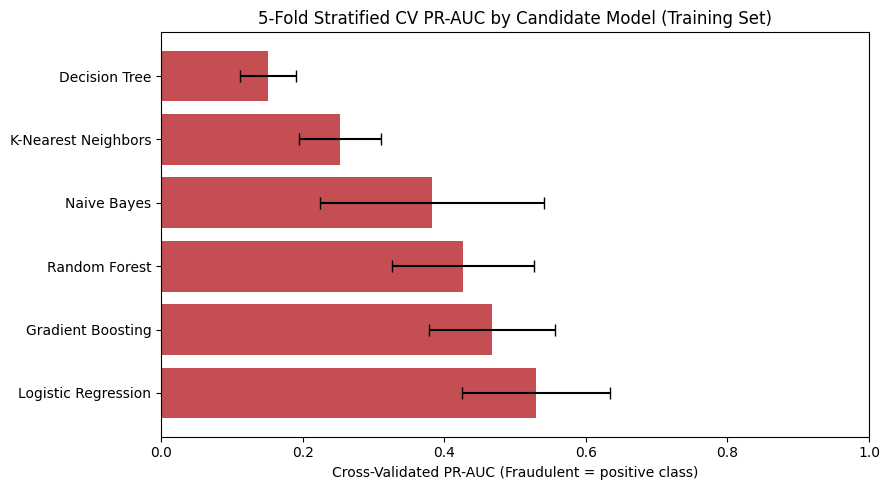

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_df = cv_results_df.sort_values("CV PR-AUC (mean)", ascending=True)
ax.barh(
    plot_df["Model"],
    plot_df["CV PR-AUC (mean)"],
    xerr=plot_df["CV PR-AUC (std)"],
    color="#C44E52",
    capsize=4
)
ax.set_xlabel("Cross-Validated PR-AUC (Fraudulent = positive class)")
ax.set_title("5-Fold Stratified CV PR-AUC by Candidate Model (Training Set)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretation

Interpretation and Insights: 1) The top-ranked model by CV PR-AUC is carried forward as the leading candidate into hyperparameter tuning (Section 8), though final model choice is confirmed only after held-out test-set evaluation in Section 7, not from CV alone. 2) Recall on the fraud class matters as much as precision here: a low-recall model misses actual fraud (expensive, direct financial loss), while a low-precision model over-flags legitimate claims for manual review (an operational cost, but a smaller one) — the precision/recall columns above should be read with that asymmetry in mind, not treated as equally important. 3) Tree-based ensembles (Random Forest, Gradient Boosting) can model non-linear interactions between predictors such as `claim_amount_to_policy_limit_ratio` and `agent_flagged_history` that a linear model like Logistic Regression cannot, which matters if fraud signals in this dataset show up as combinations of features rather than individual thresholds. 4) Because SMOTE is refit per fold rather than once beforehand, the reported scores reflect how the full preprocessing-plus-resampling-plus-model pipeline would perform on genuinely unseen claims — not an optimistic, leakage-inflated estimate.